In [49]:
import os
import time
import pandas as pd
import numpy as np
import pylab as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.linear_model import LinearRegression

In [2]:
import jupyter_black
jupyter_black.load()

In [76]:
plt.style.use("../src/mpl_style.txt")

In [3]:
RESULTS_PATH = "../results/baseline_2025-06-26/research-article_aimrd_f"

In [4]:
months = np.arange(1, 13)
years = np.arange(2000, 2025)

In [5]:
freqs_df = pd.read_csv(
    os.path.join(RESULTS_PATH, "introduction", "freqs_df.csv.gz"),
    compression="gzip",
    index_col=0,
)

In [6]:
next(os.walk(RESULTS_PATH))[1]

['full', 'methods', 'discussion', 'results', 'introduction', 'abstract']

In [7]:
freqs_df = freqs_df.drop(
    ["7-2025", "8-2025", "9-2025", "10-2025", "11-2025", "12-2025"], axis=1
)
freqs_df = freqs_df[freqs_df.index.str.len() > 3]

In [8]:
freqs_df.shape[0]

647667

In [9]:
y = freqs_df.loc["delve"]

In [10]:
y

1-2000    0.011628
2-2000    0.014085
3-2000    0.012195
4-2000    0.012821
5-2000    0.010101
            ...   
2-2025    0.008339
3-2025    0.008447
4-2025    0.007838
5-2025    0.007517
6-2025    0.005513
Name: delve, Length: 306, dtype: float64

In [11]:
end_date = "11-2022"
end_date_i = list(y.index.values).index(end_date)
y_i = y.index.values[end_date_i - 23 : end_date_i + 1]

In [12]:
len(y) - end_date_i

32

In [13]:
y[y_i].values

array([0.000962  , 0.00116279, 0.00084602, 0.00097598, 0.00071105,
       0.00056566, 0.00061963, 0.00073195, 0.00104959, 0.00058053,
       0.00059448, 0.00084055, 0.00099368, 0.00115512, 0.00087535,
       0.00065939, 0.00100773, 0.00048201, 0.00116604, 0.00071965,
       0.00109632, 0.00114173, 0.00121183, 0.00175006])

In [14]:
%%time
reg = LinearRegression().fit(np.arange(len(y_i)).reshape(-1, 1), y[y_i])

CPU times: user 1.49 ms, sys: 2.01 ms, total: 3.51 ms
Wall time: 3.5 ms


In [15]:
proj = reg.predict(np.arange(len(y_i) + (len(y) - end_date_i)).reshape(-1, 1))

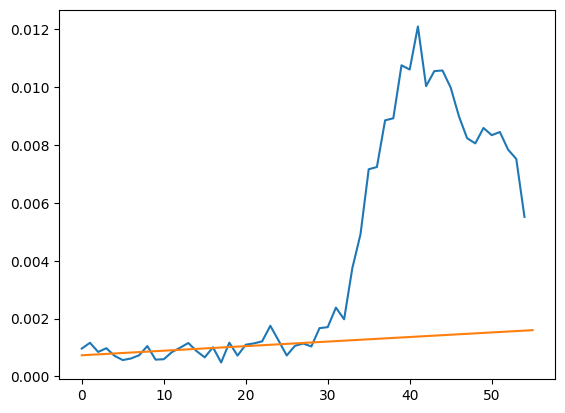

In [16]:
plt.plot(np.arange(len(y) - (end_date_i - len(y_i) + 1)), y[y_i[0] :])
plt.plot(np.arange(len(y) - (end_date_i - len(y_i))), proj)

In [17]:
pred_range = 24  # make predictions based on 24 prior months
end_date = "11-2022"  # last date to train reg with
end_date_i = list(freqs_df.columns.values).index(end_date)
start_date_i = end_date_i - pred_range
y_i_all = freqs_df.columns.values[start_date_i:]
y_i_pred = y_i_all[:pred_range]

In [18]:
proj = np.zeros((freqs_df.shape[0], len(y_i_all)))

In [29]:
freqs_df

,1-2000,2-2000,3-2000,4-2000,5-2000,6-2000,7-2000,8-2000,9-2000,10-2000,...,9-2024,10-2024,11-2024,12-2024,1-2025,2-2025,3-2025,4-2025,5-2025,6-2025
aaaa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.022727,0.012658,...,0.000089,0.000165,0.000086,0.000093,0.000078,0.000179,0.000171,0.000092,0.000098,0.000221
aaaaa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000178,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
aaaaaa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000178,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
aaaaaaa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000089,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
aaaaaaaa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000089,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzessa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000089,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
zzys,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000089,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
zzzs,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000089,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221
zzzssa,0.011628,0.014085,0.012195,0.012821,0.010101,0.013514,0.018519,0.012821,0.011364,0.012658,...,0.000089,0.000083,0.000086,0.000093,0.000078,0.000090,0.000085,0.000092,0.000098,0.000221


In [33]:
selection = ["delve", "crucial", "potential", "these", "significant", "important"]

In [35]:
freqs_df.loc[selection][y_i_all]

,11-2020,12-2020,1-2021,2-2021,3-2021,4-2021,5-2021,6-2021,7-2021,8-2021,...,9-2024,10-2024,11-2024,12-2024,1-2025,2-2025,3-2025,4-2025,5-2025,6-2025
delve,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.000620,0.000732,0.001050,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
crucial,0.111918,0.105339,0.112126,0.109222,0.109084,0.110390,0.111354,0.109209,0.114427,0.114493,...,0.233223,0.227843,0.239386,0.236901,0.259251,0.245046,0.262884,0.260421,0.261031,0.244322
potential,0.353320,0.352766,0.351412,0.360068,0.348649,0.348325,0.345131,0.353342,0.348487,0.354150,...,0.422155,0.422099,0.427224,0.423255,0.436924,0.442482,0.456997,0.461084,0.473741,0.469019
these,0.695420,0.687831,0.695183,0.690440,0.690841,0.690072,0.686545,0.694214,0.690794,0.685035,...,0.752072,0.752930,0.761643,0.756712,0.769945,0.776024,0.776195,0.779786,0.794807,0.794046
significant,0.220710,0.220106,0.231395,0.219120,0.219369,0.221047,0.228364,0.226628,0.229831,0.225925,...,0.341503,0.340815,0.359808,0.357804,0.366823,0.362683,0.383618,0.393121,0.401015,0.374862
important,0.409509,0.400770,0.416113,0.408968,0.401802,0.401209,0.398626,0.402370,0.402733,0.401382,...,0.327422,0.341475,0.340252,0.334197,0.324356,0.331122,0.318942,0.308927,0.306521,0.316648


In [46]:
secs = next(os.walk(RESULTS_PATH))[1]
selection_dfs = {}
for sec in secs:
    df = pd.read_csv(
        os.path.join(RESULTS_PATH, sec, "freqs_df.csv.gz"),
        compression="gzip",
        index_col=0,
    )
    selection_dfs[sec] = df.loc[selection][y_i_all]

In [64]:
x_months = np.arange(2020 + (10 / 12), 2025 + (5 / 12), 1 / 12)

In [72]:
word_dfs = {}
for word in selection:
    word_dict = {}
    for sec in secs:
        word_dict[sec] = selection_dfs[sec].loc[word].values
    df = pd.DataFrame.from_dict(word_dict, orient="index", columns=x_months)
    df = pd.melt(df, ignore_index=False).reset_index()
    df = df.rename(
        columns={"index": "section", "variable": "time", "value": "frequency"}
    )
    word_dfs[word] = df

In [73]:
word_dfs["delve"]

,section,time,frequency
0,full,2020.833333,0.003403
1,methods,2020.833333,0.000184
2,discussion,2020.833333,0.002115
3,results,2020.833333,0.000644
4,introduction,2020.833333,0.000828
...,...,...,...
331,methods,2025.416667,0.002426
332,discussion,2025.416667,0.016097
333,results,2025.416667,0.011246
334,introduction,2025.416667,0.005513


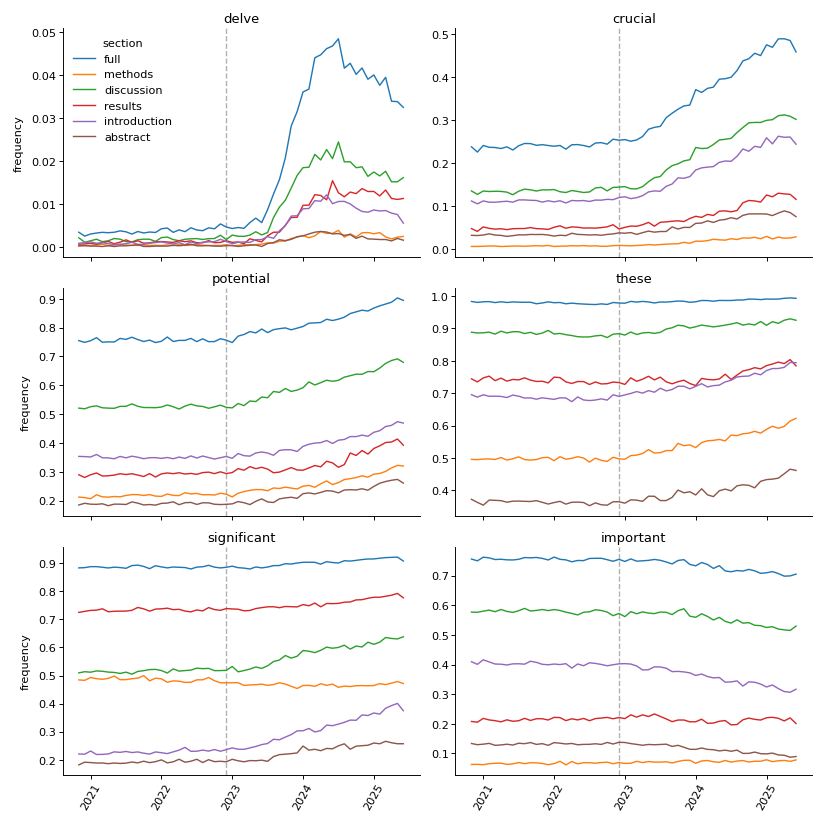

In [94]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(6, 6), layout="constrained")

for i, word in enumerate(selection):
    ax = axs.flat[i]
    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(data=word_dfs[word], x="time", y="frequency", hue="section", ax=ax)
    ax.set_title(word)
    ax.set_xlabel(None)
    if i < 4:
        ax.set_xticks([2021, 2022, 2023, 2024, 2025])
        ax.set_xticklabels([])
    else:
        ax.set_xticks([2021, 2022, 2023, 2024, 2025])
        ax.set_xticklabels([2021, 2022, 2023, 2024, 2025], rotation=60)
    if i in [1, 3, 5]:
        ax.set_ylabel(None)
    if not i == 0:
        ax.get_legend().set_visible(False)

In [41]:
word_df

,11-2020,12-2020,1-2021,2-2021,3-2021,4-2021,5-2021,6-2021,7-2021,8-2021,...,9-2024,10-2024,11-2024,12-2024,1-2025,2-2025,3-2025,4-2025,5-2025,6-2025
full,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.00062,0.000732,0.00105,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
methods,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.00062,0.000732,0.00105,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
discussion,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.00062,0.000732,0.00105,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
results,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.00062,0.000732,0.00105,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
introduction,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.00062,0.000732,0.00105,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
abstract,0.000828,0.000962,0.001163,0.000846,0.000976,0.000711,0.000566,0.00062,0.000732,0.00105,...,0.009981,0.008995,0.008234,0.008054,0.008587,0.008339,0.008447,0.007838,0.007517,0.005513
